In [24]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Load the dataset
df = pd.read_csv("notebooks/seq_spoil.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9025 entries, 0 to 9024
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SEQ_NBR              9025 non-null   int64  
 1   SEQ_SCHD_START_DT    9025 non-null   object 
 2   FLEET                9025 non-null   int64  
 3   BASE                 9025 non-null   object 
 4   DIVISION             9025 non-null   object 
 5   SPOILAGE             9025 non-null   object 
 6   TOTAL_BLOCKED_HRS    4420 non-null   float64
 7   TOTAL_SPOILED_HRS    2719 non-null   float64
 8   SEQ_CAL_DAYS         9025 non-null   int64  
 9   SEQ_DUTY_DAYS        9025 non-null   int64  
 10  SEQ_TTL_FLTTIME      9025 non-null   int64  
 11  MIN_FLYTIME_PER_LEG  9025 non-null   int64  
 12  MAX_LEGS_PER_DAY     9025 non-null   int64  
 13  SEQ_TTL_LEGS         9025 non-null   int64  
 14  MORETHAN2_321_LEGS   9025 non-null   int64  
 15  IN_SEQ_DHD           9025 non-null   i

In [26]:
df.head(5)

,SEQ_NBR,SEQ_SCHD_START_DT,FLEET,BASE,DIVISION,SPOILAGE,TOTAL_BLOCKED_HRS,TOTAL_SPOILED_HRS,SEQ_CAL_DAYS,SEQ_DUTY_DAYS,...,MAX_LEGS_PER_DAY,SEQ_TTL_LEGS,MORETHAN2_321_LEGS,IN_SEQ_DHD,LAYOVER,SEQ_PATTERN,SEQ_START,FLIGHT_PATTERN,SEQ_START_HRS,SF_LOAD_TMS
0,4062,2025-02-06,320,CLT,I,NOT SPOILED,NaN,NaN,2,2,...,3,6,1,0,12,CLT-CUN-CLT-RDU-CLT-MCO-CLT,Starts10:25,1265-1210-1645-3026-3126-3126,10,2025-11-06 21:57:37.430
1,195,2024-04-17,777,DFW,I,NOT SPOILED,19.42,NaN,3,2,...,1,2,0,0,25,DFW-LHR-DFW,Starts15:15,50-51,15,2025-11-06 21:57:37.430
2,26551,2025-05-11,737,LAX,D,NOT SPOILED,NaN,NaN,3,3,...,2,6,0,0,15,SNA-DFW-ABQ-DFW-RNO-DFW-SNA,Starts7:45,1382-9-1035-324-1361-2465,7,2025-11-06 21:57:37.430
3,18556,2024-12-31,737,DFW,I,NOT SPOILED,NaN,NaN,1,1,...,2,2,0,0,1,DFW-NAS-DFW,Starts10:0,2585-2585,10,2025-11-06 21:57:37.430
4,20413,2024-07-06,737,MIA,I,NOT SPOILED,5.50,NaN,1,1,...,2,2,0,0,1,MIA-GUA-MIA,Starts11:11,2241-1258,11,2025-11-06 21:57:37.430


In [27]:
# Data cleaning
df.fillna(0, inplace=True)
df.drop_duplicates(inplace=True)
# Modify the dataset to calculate the estimated arrival time
df["SEQ_START_CLEAN"] = df["SEQ_START"].str.replace("Starts", "", regex=False)
df["SEQ_SCHD_START_DT"] = pd.to_datetime(df["SEQ_SCHD_START_DT"])
df["SEQ_START_DT"] = df["SEQ_SCHD_START_DT"] + pd.to_timedelta(df["SEQ_START_CLEAN"] + ":00")
df["ARRIVAL_ESTIMATE"] = (df["SEQ_START_DT"] + pd.to_timedelta(df["TOTAL_BLOCKED_HRS"], unit="h")+ pd.to_timedelta(df["LAYOVER"], unit="h"))
# Find the actual arrival time
df["FINAL_ARRIVAL"] = (df["SEQ_START_DT"] + pd.to_timedelta(df["TOTAL_BLOCKED_HRS"], unit="h")+ pd.to_timedelta(df["LAYOVER"], unit="h") + pd.to_timedelta(df["TOTAL_SPOILED_HRS"], unit="h"))


Identify where the variables for calculation live:

| Variable | Column Nmae | 
|---|---|
| Fleet code | FLEET |
| Departure | BASE |
| Takeoff time | SEQ_START_CLEAN | 
| Arrival estimate| ARRIVAL_ESTIMATE | 
| Final arrival time| FINAL_ARRIVAL |



Behavior of Flight Disruption when a Check pilot or Student pilot is assigned Grouped bar chart 
- disruption rate by pilot type

Behavior of Flight Disruption regarding  student operating experience  training    
- Line chart 
— disruption rate across training timeline

In [62]:
# Load the Assignment History dataset for pilot type
df_Assignment_History = pd.read_csv("data/raw/Assignment_History.csv")
# Unifiy the data to same case 
df_Assignment_History['CKP_ASSIGNED_IND'] = df_Assignment_History['CKP_ASSIGNED_IND'].str.upper()


/var/folders/05/nr6c3d_n40sbhlx02vwk20hc0000gn/T/ipykernel_17372/3949310471.py:2: DtypeWarning: Columns (32,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_Assignment_History = pd.read_csv("data/raw/Assignment_History.csv")


In [51]:
# Create a joined dataset for the variables above
joined_df = df.loc[:, ['FLEET', 'BASE', 'SEQ_START_CLEAN','ARRIVAL_ESTIMATE', 'FINAL_ARRIVAL','TOTAL_SPOILED_HRS', 'SEQ_NBR']]


In [64]:
# create a copy of the joined_df for analysis
analysis_df = joined_df.merge(
    df_Assignment_History[['SEQ_NBR','STUDENT_ASSIGNED_IND', 'CKP_ASSIGNED_IND','IS_STUDENT_OE_STUDENT']],
    how='left',
    on='SEQ_NBR'
)
analysis_df.drop_duplicates(inplace=True)
analysis_df.dropna(inplace=True)

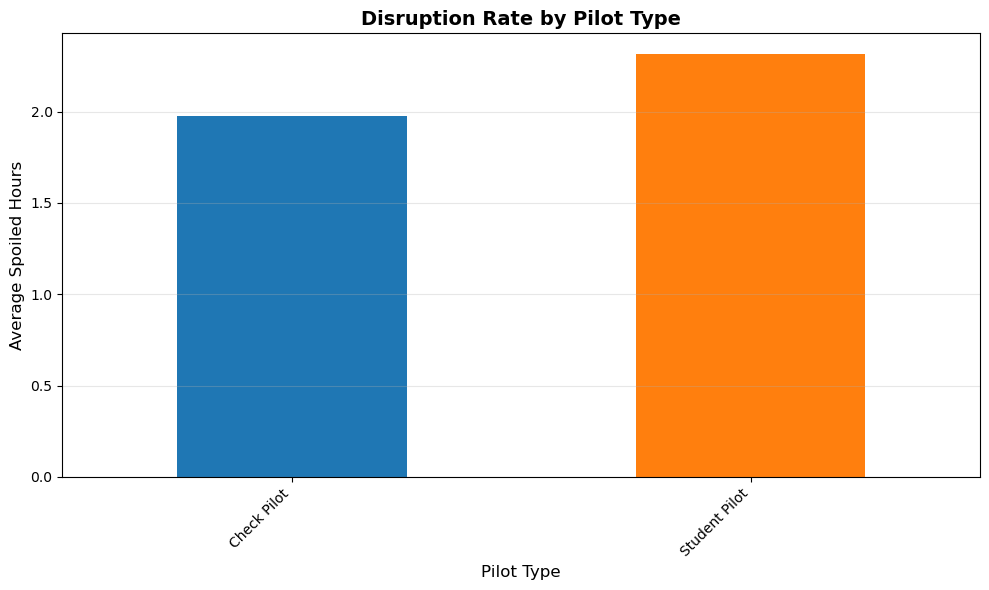

Check Pilot      1.978382
Student Pilot    2.313453
dtype: float64


In [68]:
# Disruption rate by pilot type

# Calculate average spoiled hours by pilot type
check_pilot = analysis_df[analysis_df['CKP_ASSIGNED_IND'] == 'TRUE']['TOTAL_SPOILED_HRS'].mean()
student_pilot = analysis_df[analysis_df['STUDENT_ASSIGNED_IND'] == True]['TOTAL_SPOILED_HRS'].mean()

disruption_by_pilot = pd.Series({
    'Check Pilot': check_pilot,
    'Student Pilot': student_pilot
})

# Create bar chart
plt.figure(figsize=(10, 6))
disruption_by_pilot.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Disruption Rate by Pilot Type', fontsize=14, fontweight='bold')
plt.xlabel('Pilot Type', fontsize=12)
plt.ylabel('Average Spoiled Hours', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display the values
print(disruption_by_pilot)